In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, RealData
from scipy.stats import linregress

All the initial Frequency and current data plotted. The error in the slope of the linear regression line was calculated using orthogonal distance regression (ODR) which doesn't have an r-squared value. Since the values ODR gives for the slope and y-intercept are very close to the values linregress gives, the r-squared values is just taken from linregress to estimate how good a linear fit is (its very good).

Slope = 3.698 ± 0.006 Hz/mA
Intercept = 1994.326 ± 0.429 Hz

R^2 = 0.99994


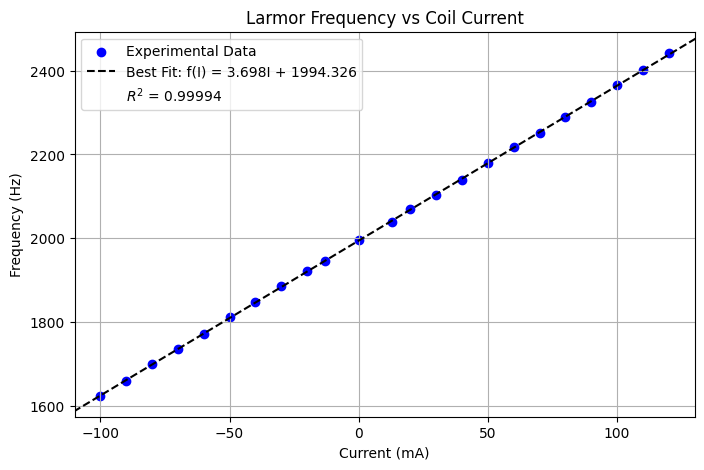

In [13]:
# mA
current = np.array([
     0, -13, -20, -30, -40, -50, -60, -70, -80, -90, -100,
     13,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120
])

# Hz
frequency = np.array([
    1995, 1946, 1922, 1886, 1847, 1811, 1772, 1736, 1701, 1659, 1624,
    2039, 2069, 2103, 2139, 2179, 2217, 2252, 2289, 2325, 2365, 2401, 2443
])

# Uncertainties
current_uncertainty = np.full_like(current, 1.0, dtype=float)      # ±1 mA
frequency_uncertainty = np.full_like(frequency, 2.0, dtype=float) # ±2 Hz

# Linear model: f(I) = mI + b
def linear_model(beta, x):
    m, b = beta
    return m*x + b

model = Model(linear_model)

data = RealData(current, frequency, sx=current_uncertainty, sy=frequency_uncertainty)

odr = ODR(data, model, beta0=[3.7, 1994]) #beta0=[3.7, 1995] is just a guess as to what the slope m and y-intercept b will be which helps speed up the calculation
output = odr.run() #actually calculates the errors in m and b

slope, intercept = output.beta
slope_uncertainty, intercept_uncertainty = output.sd_beta

print(f"Slope = {slope:.3f} ± {slope_uncertainty:.3f} Hz/mA")
print(f"Intercept = {intercept:.3f} ± {intercept_uncertainty:.3f} Hz")

linregress_result = linregress(current, frequency)
r_value = linregress_result.rvalue
    
x_fit = np.linspace(min(current) - 25, max(current) + 25, 500)
y_fit = slope * x_fit + intercept

# Print regression results
print(f"\nR^2 = {r_value**2:.5f}")

plt.figure(figsize=(8,5))
plt.scatter(current, frequency, label='Experimental Data', color='b')

plt.plot(x_fit, y_fit, label=f'Best Fit: f(I) = {slope:.3f}I + {intercept:.3f}', linestyle='--', color='k')
plt.plot([], [], label=f"$R^2$ = {r_value**2:.5f}", alpha=0.0) #Displays the R squared value on the legend

plt.xlabel("Current (mA)")
plt.ylabel("Frequency (Hz)")
plt.title("Larmor Frequency vs Coil Current")
plt.xlim(min(current) - 10, max(current) + 10)
plt.ylim(min(frequency) - 50, max(frequency) + 50)

plt.grid(True)
plt.legend();